In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report

# Final Machine Learning Assignment: Real or Fake Job Listing

**Submitted by:**
- Michelle S. (Last ID digits: 3625)
- Or B. (Last ID digits: 5160)

## Dataset

- **Dataset name:** Real / Fake Job Posting Prediction (`fake_job_postings.csv`)
- **Source (Kaggle):** https://www.kaggle.com/datasets/shivamb/real-or-fake-fake-jobposting-prediction
- **Size:** 17,880 job postings, 18 columns (see `df.info()` below).

## Use of AI / LLM Tools

We used an AI assistant (ChatGPT / Claude) during this project strictly as a learning and editing aid, not to produce the analysis, the code logic, or the conclusions for us:

- To get concept explanations, e.g. how Multinomial Naive Bayes works and how it should be implemented from scratch.
- To help us decide between candidate approaches, e.g. Bag-of-Words vs. TF-IDF, and why raw counts (BoW) fit a from-scratch Multinomial NB better than TF-IDF weights.
- For general explanations of course material we needed to review while working on the assignment.
- After we finished the core work ourselves, we asked it to review the finished notebook: reformat it for clarity, add explanatory markdown around each step, and point out mistakes or anything missing relative to the assignment instructions.

Representative prompts we used (paraphrased, not exact chat transcripts):
- "Explain how Multinomial Naive Bayes works and how the log-probabilities in `fit`/`predict` are computed."
- "Should we use Bag-of-Words or TF-IDF for a from-scratch Multinomial Naive Bayes classifier, and why?"
- "Review our completed notebook against the assignment instructions, point out anything missing or incorrect, and help us clean up the formatting and explanations."

### Problem Description and Dataset

The goal of this project is to determine whether a job advertisement is real or a scam. This is a **Supervised Learning** problem, and specifically a **Binary Classification** problem.

### Data Challenges (Imbalanced Data) and Quality Metric

Our dataset contains approximately 17,880 records, but suffers from a severe imbalance - only about 800 of the jobs are classified as "fake" (an extreme minority).

In a situation with such significant imbalance, using a standard Accuracy metric is ineffective because the model could receive a high score just by constantly guessing the majority class (real job) without actually learning anything. Therefore, in accordance with the assignment requirements for binary classification problems, we will evaluate the quality of our model using the F1-Score metric exclusively on the main class (the fake jobs).


In [2]:
#import the DataSet
df = pd.read_csv('fake_job_postings.csv')
#displays first 5 rows
display(df.head())

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [3]:
#Show the info of the dataset
print("\n--- Dataset Info ---")
df.info()


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-

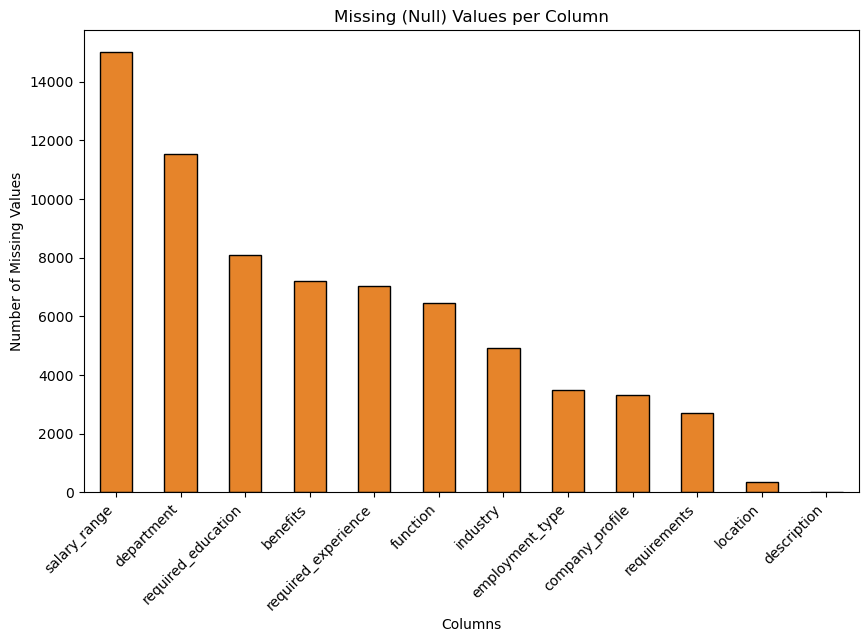

In [4]:
#Visualiztaion of the null values in every given column
null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0]
null_counts = null_counts.sort_values(ascending=False)
plt.figure(figsize=(10, 6))
null_counts.plot(kind='bar', color='#E6842A', edgecolor='black')
plt.title('Missing (Null) Values per Column')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45, ha='right')
plt.show()

In [5]:
#Checking how many as real and how many are fake (with 0 being "Real" and 1 being "Fake"
target_dist = pd.DataFrame({
    'Count': df['fraudulent'].value_counts(),
    'Percentage': (df['fraudulent'].value_counts(normalize=True) * 100).round(2).astype(str) + '%'
})
print("\n--- Target Variable Distribution ('fraudulent') ---")
target_dist


--- Target Variable Distribution ('fraudulent') ---


,Count,Percentage
fraudulent,,
0,17014,95.16%
1,866,4.84%


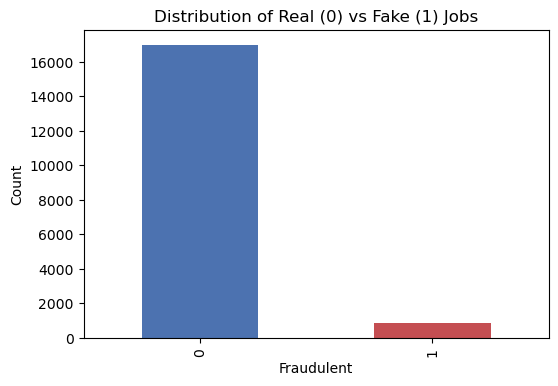

In [6]:
#We can see that there is much more real jobs then fake ones - 800 fakes and 17,014 real. We shall use the plt to visualize it.
plt.figure(figsize=(6, 4))
df['fraudulent'].value_counts().plot(kind='bar', color=['#4C72B0', '#C44E52'])
plt.title('Distribution of Real (0) vs Fake (1) Jobs')
plt.xlabel('Fraudulent')
plt.ylabel('Count')
plt.show()


In [7]:
#Now that we understood the DataSet, we can train it. The dataset was not pre-split, so we will split it ourselves. Because of the clear imbalance between the real and fake jobs, we will use the "stratify=y" - which will divide our data so that both the training and testing sets keep the same percentage of class labels as the original DataSet. We will allocate 80% towards training and 20% towards testing.

#First, we will remove the duplicates.

df_clean = df.drop_duplicates()
print (f'removed {len(df) - len(df_clean)} rows')

#Then, we will drop the "fraudulent" column.
X = df.drop(columns=['fraudulent'])
y = df['fraudulent']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("--- Train and Test Sets Shapes ---")
print(f"X_train shape: {X_train.shape}") #train should have 80% of dataset
print(f"X_test shape: {X_test.shape}") #test have 20% of dataset
print(f"y_train shape: {y_train.shape}") #same as X, but refers specifically to the "fraudulent" column
print(f"y_test shape: {y_test.shape}")

removed 0 rows
--- Train and Test Sets Shapes ---
X_train shape: (14304, 17)
X_test shape: (3576, 17)
y_train shape: (14304,)
y_test shape: (3576,)


## PART 2 -- Feature Engineering


### Feature Engineering & Preprocessing Steps

The dataset contains extensive textual information that algorithms cannot process in raw form. To manage memory efficiently and convert this data into a valid computational representation, we apply the following 5 data cleansing and vectorization steps:

1. **Cleaning Null Values:** Many columns contain missing data. We replace nulls in text columns with empty strings to prevent errors during vectorization, and fill categorical nulls with "unknown" since missing information can itself be a predictive trait for fake jobs. We also saw that `salary_range` has more than 80% null values and will not give a valid signal for real vs. fake jobs, so we decided to drop the column.
2. **Tokenization:** Splits the continuous job descriptions into individual words/tokens.
3. **Stop-Words Removal:** Filters out common words to remove noise, reducing the model's memory load and highlighting the core idea.
4. **Bag of Words (BoW):** Performs the actual vectorization. It converts text into numerical vectors of raw word counts, matching the counting assumptions our from-scratch Multinomial Naive Bayes implementation is built on.
5. **N-grams:** Captures continuous sequences of words rather than just single words, preserving short phrases that can be characteristic of fraudulent listings.


In [8]:
#STEP 1
#IMPORTANT: we clean X_train and X_test separately (not df), because df was already split
#into X_train/X_test in the previous cell - cleaning df after the split does not affect them at all.

text_cols = ['title', 'company_profile', 'description', 'requirements', 'benefits']
cat_cols = ['location', 'department', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']

for split_df in (X_train, X_test):
    split_df[text_cols] = split_df[text_cols].fillna('')
    split_df[cat_cols] = split_df[cat_cols].fillna('Unknown')
    split_df.drop(columns=['salary_range'], inplace=True, errors='ignore') #errors='ignore' so re-running this cell doesn't fail once the column is already dropped

#checking
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])
print(X_test.isnull().sum()[X_test.isnull().sum() > 0])
if X_train.isnull().sum().sum() or X_test.isnull().sum().sum():
    print("Nulls still present!")
else:
    print("No nulls remain in X_train or X_test.")


Series([], dtype: int64)
Series([], dtype: int64)
No nulls remain in X_train or X_test.


In [9]:
#STEP 2 - Tokenization
#We merge the text columns into one field per row, then split that text into individual lowercase word tokens.
#We use a simple regex tokenizer (matches sklearn's own default pattern: alphabetic words of length >= 2) so the result is a plain list of tokens we can inspect before handing it to any vectorizer.
import re

X_train['full_text'] = X_train[text_cols].agg(' '.join, axis=1)
X_test['full_text'] = X_test[text_cols].agg(' '.join, axis=1)

def simple_tokenize(text):
    return re.findall(r"\b[a-zA-Z]{2,}\b", text.lower())

X_train['tokens'] = X_train['full_text'].apply(simple_tokenize)
X_test['tokens'] = X_test['full_text'].apply(simple_tokenize)

print("--- Train Example 1: raw text (first 150 chars) ---")
print(X_train['full_text'].iloc[0][:150])
print("--- Train Example 1: tokens (first 20) ---")
print(X_train['tokens'].iloc[0][:20])

print("\n--- Train Example 2: raw text (first 150 chars) ---")
print(X_train['full_text'].iloc[1][:150])
print("--- Train Example 2: tokens (first 20) ---")
print(X_train['tokens'].iloc[1][:20])

#We also show the same step applied to the Test set, to confirm it is cleaned/tokenized
#the exact same way (using the tokenizer function only -- no statistics are fit on test).
print("\n--- Test Example 1: raw text (first 150 chars) ---")
print(X_test['full_text'].iloc[0][:150])
print("--- Test Example 1: tokens (first 20) ---")
print(X_test['tokens'].iloc[0][:20])


--- Train Example 1: raw text (first 150 chars) ---
Contact Center Representatives Tidewater Finance Co. was established in 1992 for the initial purpose of purchasing, and servicing retail installment c
--- Train Example 1: tokens (first 20) ---
['contact', 'center', 'representatives', 'tidewater', 'finance', 'co', 'was', 'established', 'in', 'for', 'the', 'initial', 'purpose', 'of', 'purchasing', 'and', 'servicing', 'retail', 'installment', 'contracts']

--- Train Example 2: raw text (first 150 chars) ---
Customer Service Associate  Novitex Enterprise Solutions, formerly Pitney Bowes Management Services, delivers innovative document and communications m
--- Train Example 2: tokens (first 20) ---
['customer', 'service', 'associate', 'novitex', 'enterprise', 'solutions', 'formerly', 'pitney', 'bowes', 'management', 'services', 'delivers', 'innovative', 'document', 'and', 'communications', 'management', 'solutions', 'that', 'help']

--- Test Example 1: raw text (first 150 chars) ---
EXCE

In [10]:
#STEP 3 - Stop-Words Removal
#Common words ("the", "and", "to", ...) carry no predictive signal and just add noise/memory overhead,
#so we filter them out of the token lists using sklearn's built-in English stop-word list.
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def remove_stopwords(tokens):
    return [t for t in tokens if t not in ENGLISH_STOP_WORDS]

X_train['tokens_clean'] = X_train['tokens'].apply(remove_stopwords)
X_test['tokens_clean'] = X_test['tokens'].apply(remove_stopwords)

print("--- Train Example 1: tokens before stop-word removal (first 20) ---")
print(X_train['tokens'].iloc[0][:20])
print("--- Train Example 1: tokens after stop-word removal (first 20) ---")
print(X_train['tokens_clean'].iloc[0][:20])

print(f"\nAvg tokens per row before: {X_train['tokens'].apply(len).mean():.1f}")
print(f"Avg tokens per row after:  {X_train['tokens_clean'].apply(len).mean():.1f}")

#Same step shown on the Test set (removal only looks up a fixed stop-word list, so there is
#no risk of leaking train-only information into this step).
print("\n--- Test Example 1: tokens before stop-word removal (first 20) ---")
print(X_test['tokens'].iloc[0][:20])
print("--- Test Example 1: tokens after stop-word removal (first 20) ---")
print(X_test['tokens_clean'].iloc[0][:20])


--- Train Example 1: tokens before stop-word removal (first 20) ---
['contact', 'center', 'representatives', 'tidewater', 'finance', 'co', 'was', 'established', 'in', 'for', 'the', 'initial', 'purpose', 'of', 'purchasing', 'and', 'servicing', 'retail', 'installment', 'contracts']
--- Train Example 1: tokens after stop-word removal (first 20) ---
['contact', 'center', 'representatives', 'tidewater', 'finance', 'established', 'initial', 'purpose', 'purchasing', 'servicing', 'retail', 'installment', 'contracts', 'divisions', 'tidewater', 'credit', 'services', 'providing', 'indirect', 'consumer']

Avg tokens per row before: 372.5
Avg tokens per row after:  230.0

--- Test Example 1: tokens before stop-word removal (first 20) ---
['excellent', 'er', 'rn', 'opportunity', 'available', 'now', 'our', 'client', 'located', 'in', 'urban', 'il', 'is', 'looking', 'for', 'an', 'er', 'rn', 'to', 'become']
--- Test Example 1: tokens after stop-word removal (first 20) ---
['excellent', 'er', 'rn', 'oppo

In [11]:
#STEP 4 - Bag of Words (BoW)
#Converts the cleaned tokens into numerical vectors of raw word counts (how many times each word appears in the document). We use raw counts instead of TF-IDF because Multinomial Naive Bayes is built around counting: Multinomial NB models P(word|class) as a word-count frequency, We feed CountVectorizer our already-tokenized lists directly (tokenizer/preprocessor set to identity, token_pattern=None) so it does NOT re-tokenize the raw text - it just counts our tokens.
from sklearn.feature_extraction.text import CountVectorizer

bow_unigram = CountVectorizer(
    tokenizer=lambda tokens: tokens,
    preprocessor=lambda tokens: tokens,
    token_pattern=None,
    max_features=5000
)
X_train_bow_uni = bow_unigram.fit_transform(X_train['tokens_clean'])
X_test_bow_uni = bow_unigram.transform(X_test['tokens_clean'])

print("--- BoW (unigrams only) ---")
print(f"X_train_bow_uni shape: {X_train_bow_uni.shape}")
print(f"X_test_bow_uni shape: {X_test_bow_uni.shape}")
print("\nTrain Example 1 vector (non-zero entries):")
print(X_train_bow_uni[0])


--- BoW (unigrams only) ---
X_train_bow_uni shape: (14304, 5000)
X_test_bow_uni shape: (3576, 5000)

Train Example 1 vector (non-zero entries):
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 181 stored elements and shape (1, 5000)>
  Coords	Values
  (0, 972)	2
  (0, 680)	4
  (0, 3790)	2
  (0, 4568)	8
  (0, 1788)	5
  (0, 1599)	1
  (0, 2281)	1
  (0, 3584)	1
  (0, 3581)	1
  (0, 4072)	1
  (0, 3852)	2
  (0, 2317)	1
  (0, 994)	1
  (0, 1344)	1
  (0, 1094)	4
  (0, 4070)	2
  (0, 3561)	2
  (0, 2260)	2
  (0, 969)	2
  (0, 3083)	1
  (0, 2889)	2
  (0, 390)	1
  (0, 1790)	1
  (0, 3765)	1
  (0, 855)	1
  :	:
  (0, 1574)	1
  (0, 3071)	1
  (0, 1487)	1
  (0, 325)	1
  (0, 3721)	1
  (0, 3621)	1
  (0, 148)	1
  (0, 4083)	1
  (0, 2721)	1
  (0, 4308)	3
  (0, 3761)	1
  (0, 2829)	1
  (0, 714)	1
  (0, 3544)	1
  (0, 2535)	1
  (0, 2235)	1
  (0, 3022)	1
  (0, 1486)	1
  (0, 2236)	1
  (0, 1492)	1
  (0, 2332)	1
  (0, 144)	1
  (0, 4416)	1
  (0, 1537)	1
  (0, 3245)	1


In [12]:
#STEP 5 - N-grams
#Single words alone lose context (e.g. "not" and "guaranteed" separately mean less than the phrase
#"not guaranteed"). We extend the same CountVectorizer to also capture 2-word sequences (bigrams),
#which preserves short phrases that can be characteristic of fraudulent listings.
#This is our FINAL feature representation, used for modeling going forward.
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(
    tokenizer=lambda tokens: tokens,
    preprocessor=lambda tokens: tokens,
    token_pattern=None,
    ngram_range=(1, 2),
    max_features=30000
)
X_train_vec = bow.fit_transform(X_train['tokens_clean'])
X_test_vec = bow.transform(X_test['tokens_clean'])

print("--- BoW with N-grams (unigrams + bigrams) - FINAL ---")
print(f"X_train_vec shape: {X_train_vec.shape}")
print(f"X_test_vec shape: {X_test_vec.shape}")

sample_bigrams = [f for f in bow.get_feature_names_out() if ' ' in f][:10]
print(f"\nExample bigram features learned: {sample_bigrams}")

print("\nTrain Example 1 vector (non-zero entries):")
print(X_train_vec[0])

#Same final representation shown for a Test example. bow.transform() (not fit_transform())
#is used on X_test, so the vocabulary/statistics come only from the training set.
print("\nTest Example 1 vector (non-zero entries):")
print(X_test_vec[0])


--- BoW with N-grams (unigrams + bigrams) - FINAL ---
X_train_vec shape: (14304, 30000)
X_test_vec shape: (3576, 30000)

Example bigram features learned: ['aan die', 'aan slag', 'abc sales', 'abc supply', 'abilities great', 'abilities required', 'ability adapt', 'ability adhere', 'ability analyze', 'ability apply']

Train Example 1 vector (non-zero entries):
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 426 stored elements and shape (1, 30000)>
  Coords	Values
  (0, 5414)	2
  (0, 3711)	4
  (0, 22305)	2
  (0, 27250)	8
  (0, 10384)	5
  (0, 9190)	1
  (0, 13314)	1
  (0, 21344)	1
  (0, 21337)	1
  (0, 24085)	1
  (0, 22729)	2
  (0, 13469)	1
  (0, 5523)	1
  (0, 7742)	1
  (0, 5960)	4
  (0, 23972)	2
  (0, 21242)	2
  (0, 13123)	2
  (0, 5388)	2
  (0, 18398)	1
  (0, 17122)	2
  (0, 1879)	1
  (0, 10440)	1
  (0, 22192)	1
  (0, 4618)	1
  :	:
  (0, 21074)	1
  (0, 14640)	1
  (0, 4856)	1
  (0, 12973)	1
  (0, 5972)	1
  (0, 24042)	1
  (0, 19802)	1
  (0, 4892)	1
  (0, 17930)	1
  (0, 23192)	1
  

In [13]:
#STEP 6 - Add Boolean Meta-Features
#On top of the text-based BoW/n-gram features, we attach 3 columns that are already clean 0/1 flags
#and need no encoding: telecommuting, has_company_logo, has_questions. Fake job posts tend to differ from real ones on these (e.g. missing a company logo, no screening questions), so they add cheap extra signal.
from scipy.sparse import hstack, csr_matrix

meta_cols = ['telecommuting', 'has_company_logo', 'has_questions']

X_train_meta = csr_matrix(X_train[meta_cols].values)
X_test_meta = csr_matrix(X_test[meta_cols].values)

X_train_final = hstack([X_train_vec, X_train_meta]).tocsr()
X_test_final = hstack([X_test_vec, X_test_meta]).tocsr()

print("--- Final feature matrix (BoW unigrams+bigrams + 3 boolean meta-features) ---")
print(f"X_train_final shape: {X_train_final.shape}")  #5000 BoW columns + 3 meta columns
print(f"X_test_final shape: {X_test_final.shape}")

--- Final feature matrix (BoW unigrams+bigrams + 3 boolean meta-features) ---
X_train_final shape: (14304, 30003)
X_test_final shape: (3576, 30003)


## PART 3 -- Algorithm Implementation: Multinomial Naive Bayes (from scratch)

### Why Multinomial Naive Bayes?

Our features are word/bigram counts (Bag-of-Words), so the *Multinomial* event model -- which assumes each feature is a count drawn from a per-class word-frequency distribution -- is the natural fit. This is different from *Bernoulli* Naive Bayes (which only looks at whether a word is present or absent) or *Gaussian* Naive Bayes (which assumes continuous, normally-distributed features).

### How it works

Naive Bayes classifies a document `x` into the class `c` that maximizes the posterior probability, using Bayes' theorem:

`P(c | x)` is proportional to `P(c) * P(x | c)`

- **`P(c)`** -- the *class prior*: how common each class (real / fake) is in the training data.
- **`P(x | c)`** -- the *likelihood*: under the "naive" assumption that, given the class, each word/bigram occurs independently of the others, this becomes a product over all features: `P(x | c) = product over i of P(word_i | c) ^ count_i`. This independence assumption is a simplification (word choice is not really independent), but it makes the model fast and simple to implement, and it still performs well in practice for text classification.
- **Log-space:** multiplying thousands of small probabilities underflows numerically, so we work with **log-probabilities** and turn the product into a sum: `log P(c|x) ~ log P(c) + sum over i of count_i * log P(word_i | c)`. The `predict` method computes this sum for both classes and picks the class with the higher score (`argmax`).
- **Laplace smoothing (`alpha`):** without smoothing, a word that never appeared in a class's training documents would get `P(word|c) = 0`, which would zero out the entire product the moment that word shows up in a new document. We add `alpha` to every word count (`alpha=1.0` by default) before normalizing, so unseen combinations get a small non-zero probability instead of breaking the model. `alpha` is the hyperparameter of this algorithm -- the assignment lets us change it, and a larger `alpha` smooths the distribution more heavily.

### What `fit` and `predict` do

- `fit(X, y)` computes, for each class, the log prior (`class_log_prior_`) and, for every feature (word/bigram/meta-feature), the smoothed log-probability of it occurring given that class (`feature_log_prob_`).
- `predict(X)` multiplies (in log-space, i.e. a matrix multiplication + addition) each document's feature vector by the learned `feature_log_prob_`, adds the class priors, and returns the class with the highest score per row.


In [14]:
#-------------PART 3 - ALGORITHM IMPLEMENTATION----------------
# Multinomial Naive Bayes implementation from scratch (see explanation above)

class MultinomialNB:
    def __init__(self, alpha=1.0):
        self.alpha = alpha # Laplace smoothing parameter

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        n_samples, n_features = X.shape
        
        self.class_log_prior_ = np.zeros(len(self.classes_))
        self.feature_log_prob_ = np.zeros((len(self.classes_), n_features))
        
        for idx, c in enumerate(self.classes_):
            X_c = X[y == c] 
            self.class_log_prior_[idx] = np.log(X_c.shape[0] / n_samples)
            feature_counts = np.array(X_c.sum(axis=0)).flatten()
            total_count = feature_counts.sum()
            self.feature_log_prob_[idx, :] = np.log(
                (feature_counts + self.alpha) / (total_count + self.alpha * n_features)
            )

    def predict(self, X):
        log_likelihoods = X.dot(self.feature_log_prob_.T) + self.class_log_prior_
        return self.classes_[np.argmax(log_likelihoods, axis=1)]



In [15]:
#-------------PART 4 - TRAINING----------------
# Initialize the model and train it using the final training matrix
nb_model = MultinomialNB(alpha=0.01)
nb_model.fit(X_train_final, y_train.values)
print("Model trained successfully!")

Model trained successfully!


In [16]:
#-------------PART 5 - PREDICTION & EVALUATION----------------
# Predict on the test set
y_pred = nb_model.predict(X_test_final)

# Show the first 5 predictions vs actuals (Assignment Requirement)
print("--- First 5 Predictions ---")
print("Predicted labels: ", y_pred[:5])
print("Actual labels:    ", y_test.values[:5])

# Evaluate model quality using F1-Score on the minority class (Fraudulent = 1)
f1_fake = f1_score(y_test.values, y_pred, pos_label=1)
print(f"\nF1-Score for Fake Jobs (Minority Class): {f1_fake:.4f}")

# Full classification report, for extra context alongside the single F1-Score above
print("\n--- Full Classification Report (for context) ---")
print(classification_report(y_test.values, y_pred, target_names=["Real (0)", "Fake (1)"]))


--- First 5 Predictions ---
Predicted labels:  [0 0 0 0 0]
Actual labels:     [0 0 0 0 0]

F1-Score for Fake Jobs (Minority Class): 0.8152

--- Full Classification Report (for context) ---
              precision    recall  f1-score   support

    Real (0)       0.99      0.99      0.99      3403
    Fake (1)       0.77      0.87      0.82       173

    accuracy                           0.98      3576
   macro avg       0.88      0.93      0.90      3576
weighted avg       0.98      0.98      0.98      3576

